# Investigating Data Density per Diagonal
UOT results for the cell lines dataset were not very clear. To ensure the increased density of the dataset is not increasing the effects of the major diagonal, we'll investigate the average of the selected data after thresholding per diagonal, as well as the variance.

## Imports

In [3]:
### Enabling autoreload ##
%load_ext autoreload
%autoreload 2

In [66]:
### Directories and Files ###
root = '../../../../../'
metadata_dir = root+'Generated Data/Single-to-single/sc_uot_ramani/Metadata/maxnorm_total_mass.csv'
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/ramani_cool_files' # Importing was not working with relative root+'..' approach, so replace with local data
save_dir = root+'Generated Data/Single-to-single/sc_uot_ramani/Clustering'
data_dir_sc = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'

In [5]:
### Imports ###
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append(root+'Scripts')
from hicdatautils import import_cool_dir, hic_mask_threshold, fetch_region, bin_contact_map

In [67]:
### Importing chr1, ramani ###
clrs_ramani = import_cool_dir(data_dir)
chr1s_ramani = []
for clr in clrs_ramani:
    chr1s_ramani.append(fetch_region(clr, "chr1"))
del clrs_ramani

    # Shape
shape = chr1s_ramani[0].shape[0]

### Importing chr1, sc ###
clrs_sc = import_cool_dir(data_dir_sc)
chr1s_sc = []
for clr in clrs_sc:
    chr1s_sc.append(fetch_region(clr, "chr1"))
del clrs_sc

## Helper Functions

In [68]:
def construct_diag_data(chr1s: list[np.ndarray], res: int=1, thres: int=0) -> dict:
    '''
        Returns a dictonary that describes all values per diagonal
        from the single cell data.

        Parameters
        ----------
        chr1s : list[np.ndarray]
            List of chromosome 1s to consider.
        res : int
            The resolution to bin the data to.
        thres : int
            Threshold to use for the data.

        Returns
        -------
        diag_dict : dict
            Dictionary with diagonal number as keys and a list
            of raw values as values.
    '''
    # Initializing dict
    diag_dict = {}

    # Looping through all chr1s
    for chr1 in chr1s:
        # Binning
        chr1_binned = bin_contact_map(chr1, res)

        # Extracting values and coords
        values, coords = hic_mask_threshold(chr1_binned, thres, 'percentile', 'max')

        # Looping through all values and coords
        for value, (i, j) in zip(values, coords):
            # Diagonal offset
            k = abs(i - j)

            # Adding to dictionary
            if k in diag_dict.keys():
                diag_dict[k].append(value)
            else:
                diag_dict[k] = [value]

    return diag_dict

def calc_diag_stats(diag_dict: dict) -> pd.DataFrame:
    '''
        Takes a dictionary generated by construct_diag_data and
        calculates the average, variance and counts per diagonal.

        Parameters
        ----------
        diag_dict : dict
            Dictionary with diagonal number as keys and a list
            of raw values as values.
        
        Returns
        -------
        stats_diag : pd.DataFrame
            Dataframe with diagonal number as indices and a columns describing
            the average, variance and normalized value counts of the diagonal.
    '''
    # Initialize empty list
    stats_diag_dict = {
        "k" : [],
        "average_count" : [],
        "variance" : [],
        "count/(shape-k)" : []
    }

    # Loop through key/value pairs
    for k, values in diag_dict.items():
        stats_diag_dict["k"].append(k)
        stats_diag_dict["average_count"].append(np.average(values))
        stats_diag_dict["variance"].append(np.var(values))
        stats_diag_dict["count/(shape-k)"].append(np.count_nonzero(values)/(shape-k))

    # Convert to dataframe
    stats_diag = pd.DataFrame.from_dict(stats_diag_dict).sort_values(by=["k"])
    stats_diag = stats_diag.set_index("k")

    return stats_diag

def plot_stats(stats_diag : pd.DataFrame, res : int, thres : int) -> None:
    '''
        Takes a dataframe describing the stats per diagonal and plots
        the average count, count variance and normalized counts per diagonal.

        Parameters
        ----------
        stats_diag : pd.DataFrame
            Dataframe with diagonal number as the index and count averages,
            variances and normalized counts as columns.
        res : int
            Resolution used to generate stats. Used for title.
        res : int
            Resolution used to generate stats. Used for title.
    '''
    # Initializing supfigure
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    axes = ax.flatten()

    # Averages
    axes[0].scatter(stats_diag.index, stats_diag['average_count'], s=4)
    axes[0].set_title("Average Value")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("Average Value")

    # Variance
    axes[1].scatter(stats_diag.index, stats_diag['variance'], s=4)
    axes[1].set_title("Variance")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Variance")

    # Normalized count
    axes[2].scatter(stats_diag.index, stats_diag['count/(shape-k)'], s=4)
    axes[2].set_title("Normalized Nonzero Points")
    axes[2].set_xlabel("k")
    axes[2].set_ylabel("counts/(250-k)") 

    # Suptitle
    plt.suptitle(f"Data Summary for res={res}, thres={thres}", fontweight="bold")
    return

## Summary per Res and Thres Cell Lines
Below, we'll plot data summaries per resolution and threshold of interest to see possible biases for the closer diagonals

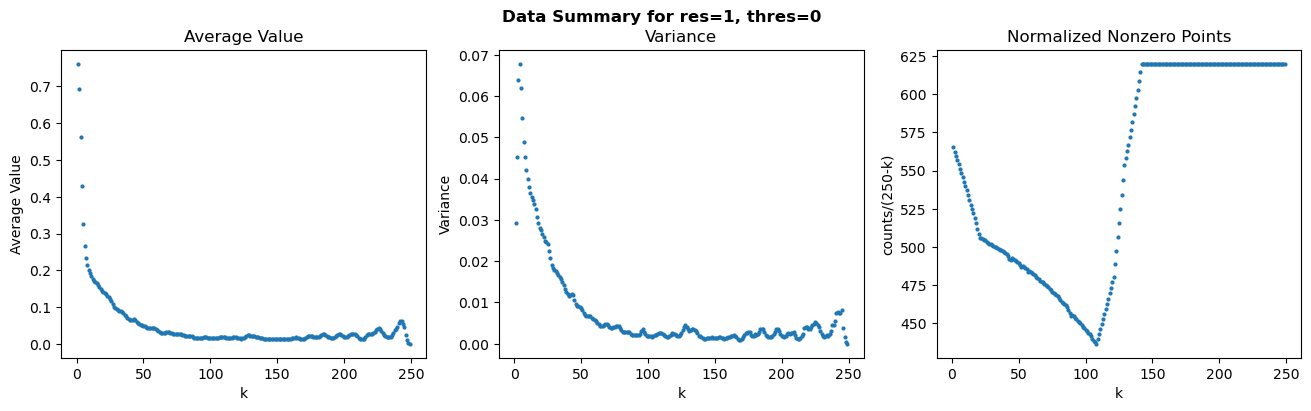

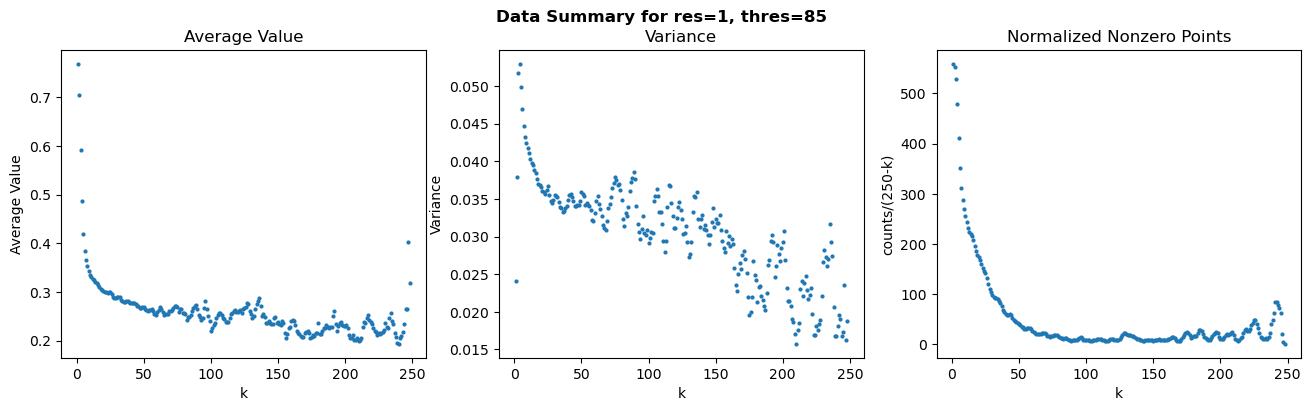

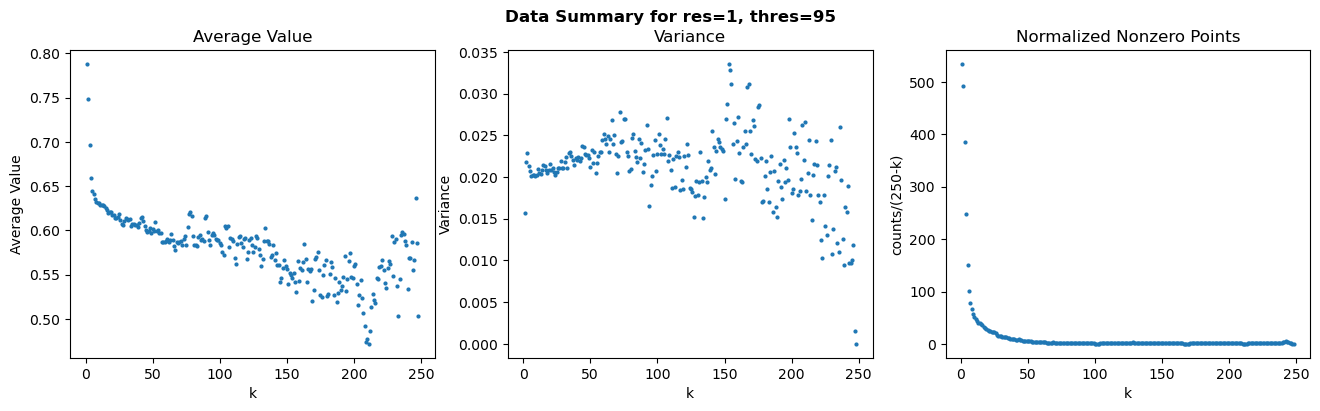

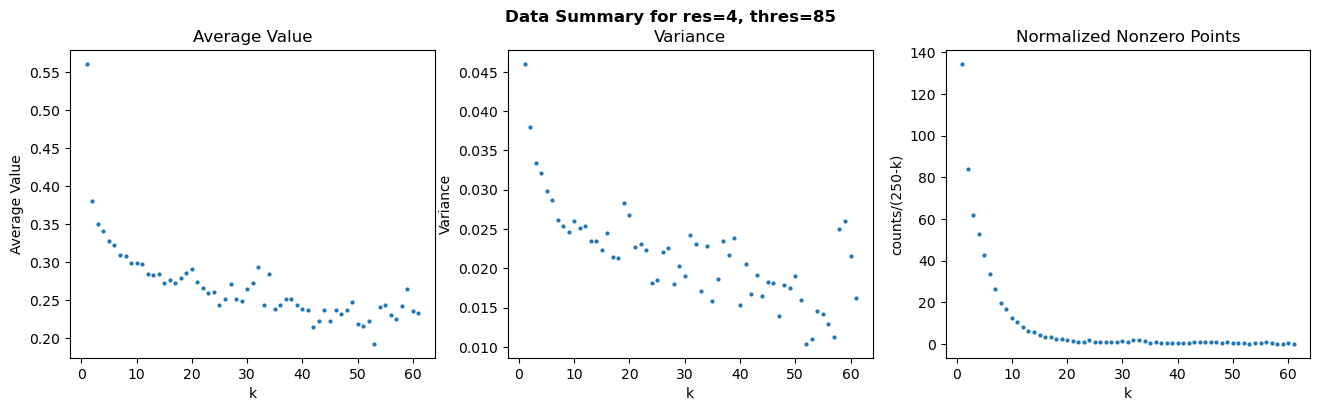

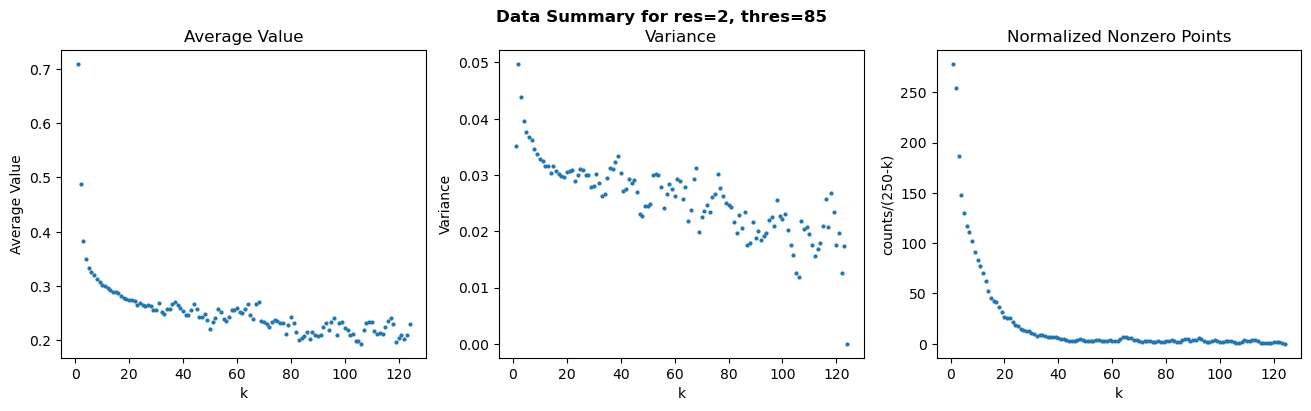

In [ ]:
res_thres_list = [
    (1, 0),
    (1, 85),
    (1, 95),
    (4, 85),
    (2, 85)
]

for res, thres in res_thres_list:
    data = construct_diag_data(chr1s_ramani, res, thres)
    stats = calc_diag_stats(data)
    plot_stats(stats, res, thres)

## Summary per Res and Thres sc
To compare, we'll calculate the same statistics for the previous dataset

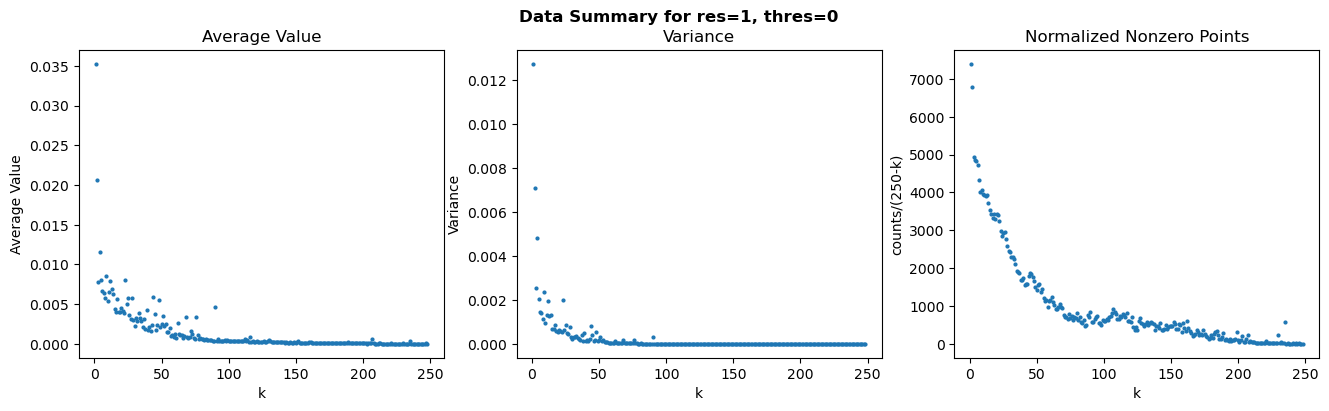

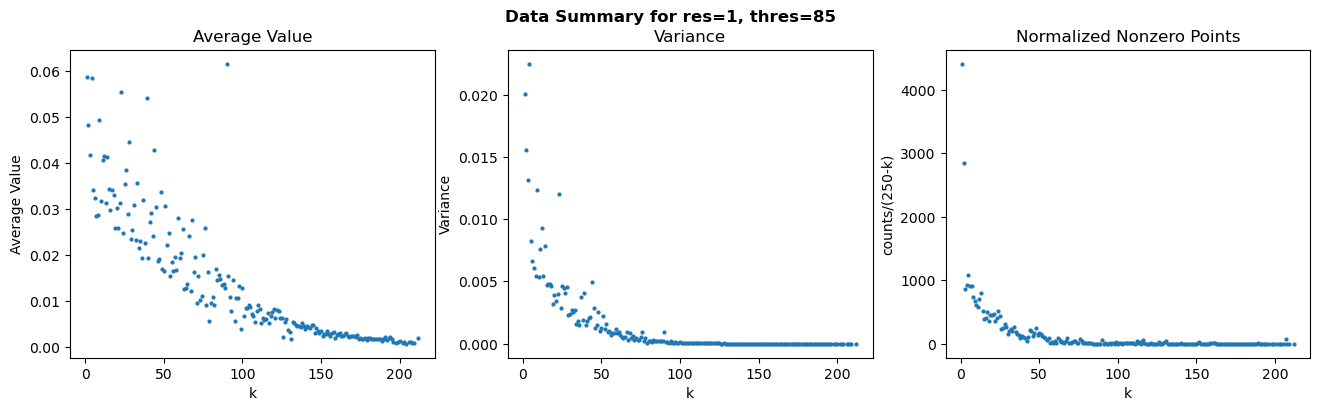

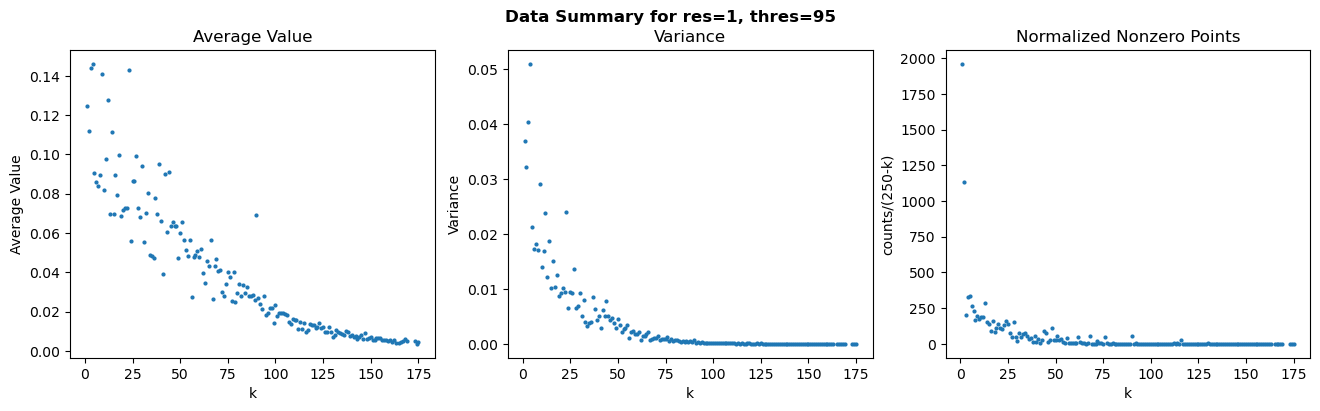

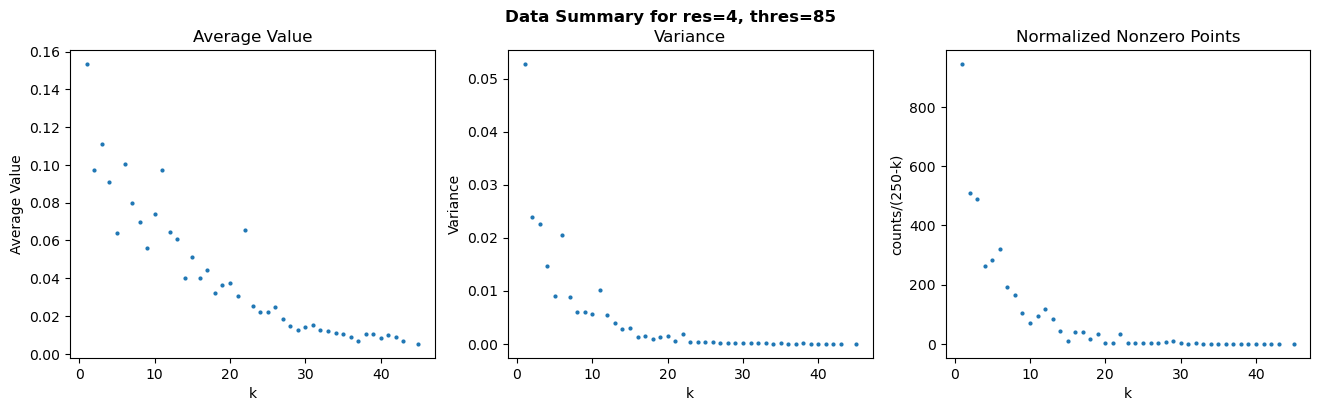

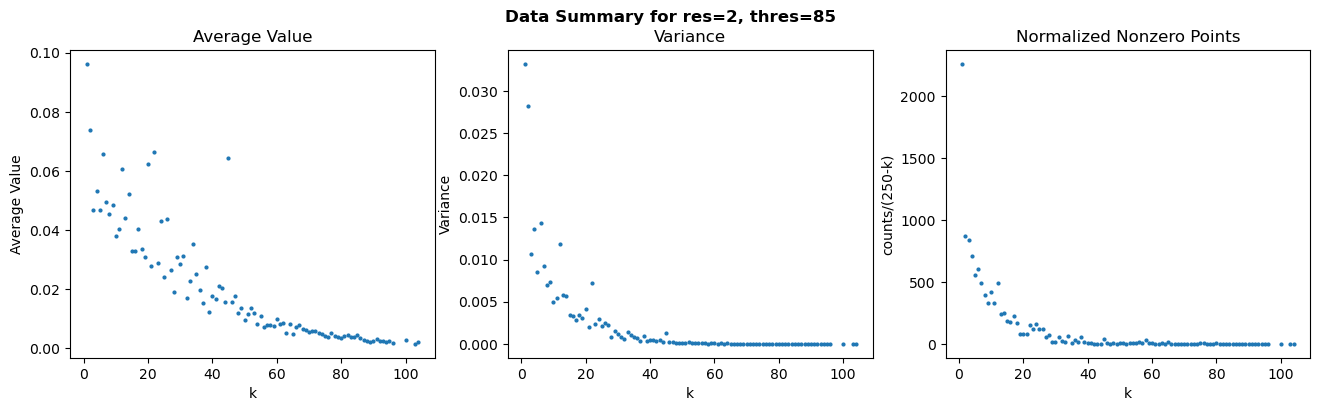

In [69]:
res_thres_list = [
    (1, 0),
    (1, 85),
    (1, 95),
    (4, 85),
    (2, 85)
]

for res, thres in res_thres_list:
    data = construct_diag_data(chr1s_sc, res, thres)
    stats = calc_diag_stats(data)
    plot_stats(stats, res, thres)